# Pourquoi le modèle réussit-il ici et échoue-t-il là ?



## 1. Reconstruction du modèle et de ses erreurs


In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import savgol_filter
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 60)

DATA = '../data/cln1/Raw'
SG_WINDOW, SG_POLY = 13, 2
CIBLE = 'dans_piece'


In [2]:
# ── Reprise à l'identique de la préparation de detection_occupation.ipynb
co2 = pd.read_csv(f'{DATA}/Mesures_Confort_Dynamique/CNL1_SERIE_CO2.txt', sep='\t',
                  encoding='latin1', usecols=['CODELIEU', 'DATE_HEURE', 'VALEUR'],
                  parse_dates=['DATE_HEURE'])
co2['VALEUR'] = pd.to_numeric(co2['VALEUR'], errors='coerce')
co2 = co2.dropna(subset=['VALEUR']).sort_values(['CODELIEU', 'DATE_HEURE'])
co2['DATE'] = co2['DATE_HEURE'].dt.normalize()
co2['deriv'] = (co2.groupby('CODELIEU')['VALEUR']
                .transform(lambda x: savgol_filter(x, SG_WINDOW, SG_POLY, deriv=1, delta=1/6)))
n = co2.groupby(['CODELIEU', 'DATE'])['VALEUR'].transform('size')
co2 = co2[n == 144].copy()
co2['tranche'] = co2.groupby(['CODELIEU', 'DATE']).cumcount()

sem = pd.read_csv(f'{DATA}/Questionnaires_Comportement/CNL1_SEMAINIER_DATA.txt',
                  sep='\t', encoding='latin1')
sem['DATE'] = pd.to_datetime(sem['DATE'], format='%d/%m/%Y')
sem = sem[sem['CODE_HEURE'].str.startswith('V_1')].copy()
sem['tranche'] = sem['CODE_HEURE'].str[2:].astype(int) - 1001
cap = (pd.read_csv(f'{DATA}/Mesures_Confort_Dynamique/CNL1_SERIE_CO2.txt', sep='\t',
                   encoding='latin1', usecols=['CODELIEU', 'IDN_PIECE'])
       .groupby('CODELIEU')['IDN_PIECE'].first())
sem['piece_capteur'] = sem['CODELIEU'].map(cap)
renseigne = sem['IDN_PIECE'].notna()
sem['dans_piece'] = renseigne & (sem['IDN_PIECE'] == sem['piece_capteur'])
presence = (sem.groupby(['CODELIEU', 'DATE', 'tranche'])
            .agg(dans_piece=('dans_piece', 'any'), n_occupants=('dans_piece', 'sum'),
                 n_declares=('IDN_PIECE', 'size'), n_renseignes=('IDN_PIECE', 'count'))
            .reset_index())
presence['n_manquants'] = presence['n_declares'] - presence['n_renseignes']

df = co2[['CODELIEU', 'DATE', 'tranche', 'VALEUR', 'deriv']].merge(
    presence, on=['CODELIEU', 'DATE', 'tranche'], how='inner')
df = df[df.groupby(['CODELIEU', 'DATE'])['VALEUR'].transform('max') < 6000]
df = df[df['n_manquants'] == 0]
df['heure'] = df['tranche'] / 6

stats_log = df.groupby('CODELIEU')['VALEUR'].agg(['mean', 'std'])
df['co2_znorm'] = ((df['VALEUR'] - df['CODELIEU'].map(stats_log['mean']))
                   / df['CODELIEU'].map(stats_log['std']).clip(lower=1e-9))

d = df.sort_values(['CODELIEU', 'DATE', 'tranche']).copy()
g = d.groupby(['CODELIEU', 'DATE'])
d['deriv_lisse'] = g['deriv'].transform(
    lambda x: savgol_filter(x, SG_WINDOW, SG_POLY) if len(x) >= SG_WINDOW else x)
for w in (3, 6):
    d[f'co2_moy_{w*10}min'] = g['co2_znorm'].transform(lambda x: x.rolling(w, min_periods=1).mean())
    d[f'deriv_moy_{w*10}min'] = g['deriv'].transform(lambda x: x.rolling(w, min_periods=1).mean())
d['co2_ecart_min'] = d['VALEUR'] - g['VALEUR'].transform('min')
d['heure_sin'] = np.sin(2 * np.pi * d['heure'] / 24)
d['heure_cos'] = np.cos(2 * np.pi * d['heure'] / 24)

FEATURES = ['co2_znorm', 'deriv', 'deriv_lisse', 'co2_moy_30min', 'co2_moy_60min',
            'deriv_moy_30min', 'deriv_moy_60min', 'co2_ecart_min', 'heure_sin', 'heure_cos']
d = d.dropna(subset=FEATURES)
print(f'{len(d):,} observations · {d["CODELIEU"].nunique()} logements')


342,698 observations · 451 logements


In [ ]:
# ── Validation croisée par groupes : chaque logement est évalué par un modèle
from sklearn.model_selection import GroupKFold

d = d.reset_index(drop=True)
d['proba'] = np.nan
gkf = GroupKFold(n_splits=5)

for i, (itr, ite) in enumerate(gkf.split(d, groups=d['CODELIEU']), 1):
    m = HistGradientBoostingClassifier(random_state=42)
    m.fit(d.loc[itr, FEATURES], d.loc[itr, CIBLE].astype(int))
    d.loc[ite, 'proba'] = m.predict_proba(d.loc[ite, FEATURES])[:, 1]
    print(f'  pli {i}/5 terminé ({len(ite):,} observations prédites)')

print(f'\nAUC globale (validation croisée) : '
      f'{roc_auc_score(d[CIBLE].astype(int), d["proba"]):.3f}')


  pli 1/5 terminé (68,542 observations prédites)
  pli 2/5 terminé (68,507 observations prédites)
  pli 3/5 terminé (68,519 observations prédites)
  pli 4/5 terminé (68,576 observations prédites)
  pli 5/5 terminé (68,554 observations prédites)

AUC globale (validation croisée) : 0.939


447 logements évaluables (4 écartés : une seule classe présente)

AUC par logement :
   10e centile : 0.884
   25e centile : 0.935
   50e centile : 0.970
   75e centile : 0.987
   90e centile : 0.994


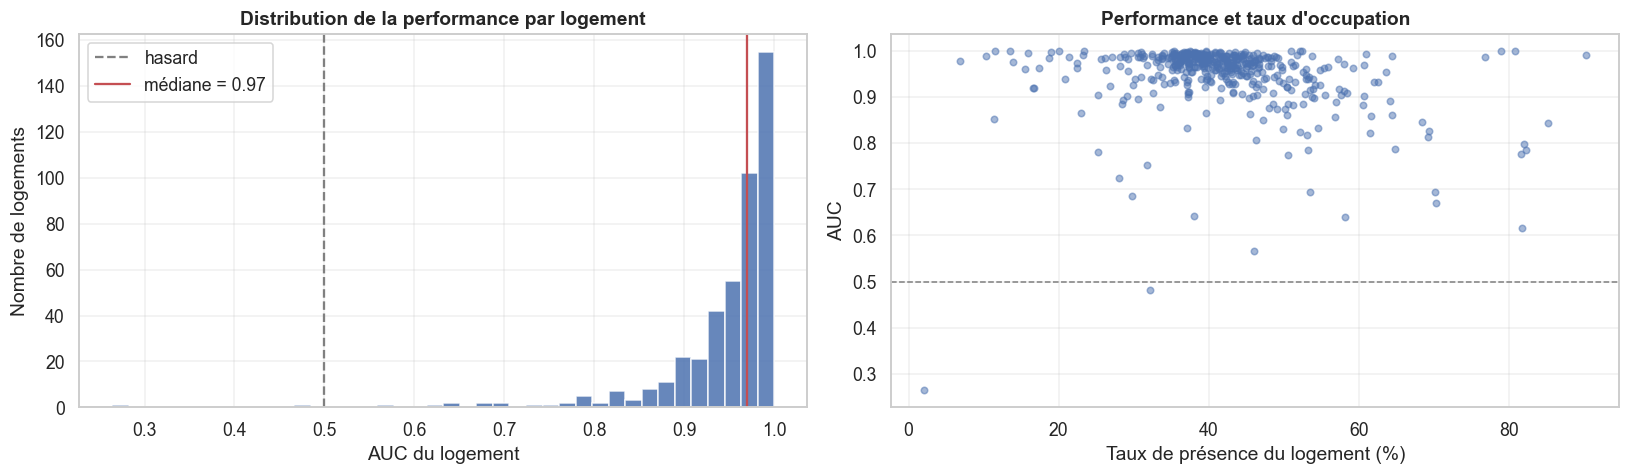

In [4]:
# ── Performance par logement : l'AUC n'est calculable que si les deux classes
# sont présentes. Un logement occupé en permanence, ou jamais, ne fournit aucune
# information discriminante et doit être écarté du croisement.
perf = (d.groupby('CODELIEU')
        .apply(lambda x: pd.Series({
            'auc': roc_auc_score(x[CIBLE].astype(int), x['proba'])
                   if x[CIBLE].nunique() > 1 else np.nan,
            'n_obs': len(x),
            'n_jours': x.groupby('DATE').ngroups,
            'taux_presence': x[CIBLE].mean(),
            'co2_median': x['VALEUR'].median(),
            'co2_amplitude': x['VALEUR'].quantile(.95) - x['VALEUR'].quantile(.05),
            'occ_max': x['n_occupants'].max(),
        })))
n_exclus = perf['auc'].isna().sum()
perf = perf.dropna(subset=['auc'])

print(f'{len(perf)} logements évaluables ({n_exclus} écartés : une seule classe présente)')
print(f'\nAUC par logement :')
for q in [0.10, 0.25, 0.50, 0.75, 0.90]:
    print(f'  {int(q*100):>3}e centile : {perf["auc"].quantile(q):.3f}')

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
axes[0].hist(perf['auc'], bins=40, color='#4C72B0', alpha=0.85)
axes[0].axvline(0.5, color='grey', lw=1.5, ls='--', label='hasard')
axes[0].axvline(perf['auc'].median(), color='#C44E52', lw=1.5,
                label=f'médiane = {perf["auc"].median():.2f}')
axes[0].set_xlabel('AUC du logement'); axes[0].set_ylabel('Nombre de logements')
axes[0].set_title('Distribution de la performance par logement', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].scatter(perf['taux_presence'] * 100, perf['auc'], s=18, alpha=0.5, color='#4C72B0')
axes[1].axhline(0.5, color='grey', lw=1, ls='--')
axes[1].set_xlabel('Taux de présence du logement (%)'); axes[1].set_ylabel('AUC')
axes[1].set_title('Performance et taux d\'occupation', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


## 2. Croisement avec les caractéristiques du logement

La performance varie fortement d'un logement à l'autre. Reste à savoir si cette
variation est structurée — liée à la ventilation, à la taille, au ménage — ou
simplement erratique.


In [5]:
KVNT_LABELS = {1: 'VMC', 2: 'Extracteurs', 3: 'Naturelle', 4: 'Aucune'}
KVSY_LABELS = {1: 'Simple flux', 2: 'Double flux'}
FC3_LABELS = {1: 'Maison individuelle', 2: 'Appart. (collectif)', 3: 'Studio (collectif)',
              4: 'Pièce indépendante', 5: 'Logement-foyer', 6: 'Ferme / bât. agricole',
              7: 'Chambre hôtel', 8: 'Construction provisoire', 9: 'Immeuble à usage pro'}
STRMEN_LABELS = {1: 'Personne seule', 2: 'Famille monoparentale',
                 3: 'Couple', 4: 'Autre ménage'}

q = pd.read_csv(f'{DATA}/Questionnaires_Comportement/CNL1_Q_LOGEMENT_MENAGE_DATA.csv',
                sep=';', encoding='latin1',
                usecols=['CODELIEU', 'KVNT', 'KVSY', 'FC3', 'STRMEN', 'HSRF', 'NPP']
                ).set_index('CODELIEU')
num = lambda c: pd.to_numeric(q[c], errors='coerce')
carac = pd.DataFrame({
    'ventilation':      num('KVNT').map(KVNT_LABELS),
    'systeme_vmc':      num('KVSY').map(KVSY_LABELS),
    'type_logement':    num('FC3').map(FC3_LABELS),
    'structure_menage': num('STRMEN').map(STRMEN_LABELS),
    'surface':          num('HSRF'),
    'nb_pieces':        num('NPP'),
})

# Pièce du capteur : le CO2 d'une chambre ne réagit pas comme celui d'un séjour
pieces = pd.read_csv(f'{DATA}/Identite_Logement/CNL1_LISTE_PIECE.csv',
                     sep=';', encoding='utf-16')
carac['piece_capteur'] = cap.map(pieces.set_index('IDN_PIECE')['TYPEPIECE'])

P = perf.join(carac)
print(f'{len(P)} logements · {P["ventilation"].notna().sum()} avec ventilation renseignée')
display(P[['auc', 'surface', 'nb_pieces', 'taux_presence']].describe().round(2))


447 logements · 447 avec ventilation renseignée


,auc,surface,nb_pieces,taux_presence
count,447.00,441.00,447.00,447.00
mean,0.95,111.48,3.84,0.42
std,0.07,62.72,1.33,0.11
min,0.26,12.00,1.00,0.02
25%,0.94,71.00,3.00,0.37
50%,0.97,98.00,4.00,0.41
75%,0.99,140.00,5.00,0.47
max,1.00,600.00,10.00,0.90


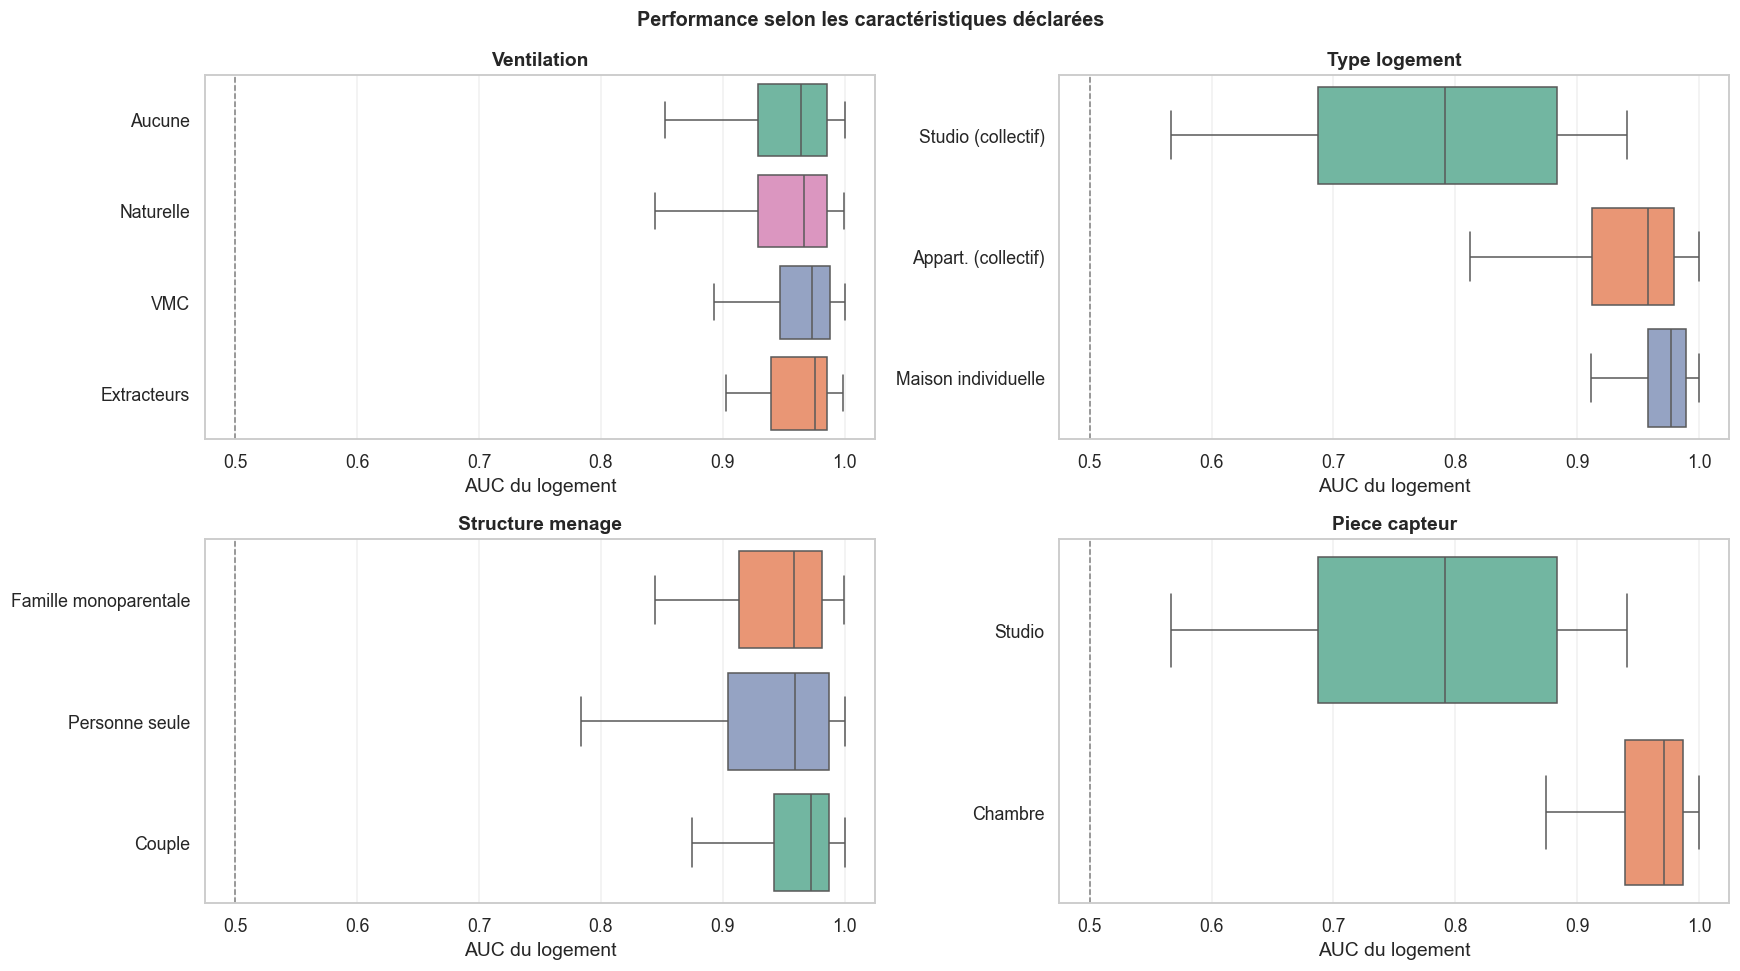


ventilation — écart entre extrêmes : 0.012
             size  median
ventilation              
Extracteurs    43   0.976
VMC           170   0.973
Naturelle     145   0.967
Aucune         89   0.964

type_logement — écart entre extrêmes : 0.186
                     size  median
type_logement                    
Maison individuelle   268   0.977
Appart. (collectif)   157   0.958
Studio (collectif)     14   0.791

structure_menage — écart entre extrêmes : 0.015
                       size  median
structure_menage                   
Couple                  329   0.973
Personne seule           78   0.959
Famille monoparentale    38   0.958

piece_capteur — écart entre extrêmes : 0.180
               size  median
piece_capteur              
Chambre         431   0.971
Studio           14   0.791


In [6]:
# ── Variables qualitatives : la performance diffère-t-elle entre catégories ?
QUALI = ['ventilation', 'type_logement', 'structure_menage', 'piece_capteur']

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
for ax, v in zip(axes.ravel(), QUALI):
    sub = P.dropna(subset=[v])
    ordre = sub.groupby(v)['auc'].median().sort_values().index
    # catégories trop rares : lecture non fiable, on les écarte de la figure
    garde = [c for c in ordre if (sub[v] == c).sum() >= 10]
    sub = sub[sub[v].isin(garde)]
    sns.boxplot(data=sub, y=v, x='auc', order=garde, ax=ax,
                hue=v, palette='Set2', legend=False, showfliers=False)
    ax.axvline(0.5, color='grey', lw=1, ls='--')
    ax.set_xlabel('AUC du logement'); ax.set_ylabel('')
    ax.set_title(v.replace('_', ' ').capitalize(), fontweight='bold')
    ax.grid(True, axis='x', alpha=0.3)

plt.suptitle('Performance selon les caractéristiques déclarées', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

for v in QUALI:
    t = P.dropna(subset=[v]).groupby(v)['auc'].agg(['size', 'median'])
    t = t[t['size'] >= 10].sort_values('median', ascending=False)
    if len(t) > 1:
        print(f'\n{v} — écart entre extrêmes : '
              f'{t["median"].max() - t["median"].min():.3f}')
        print(t.round(3).to_string())


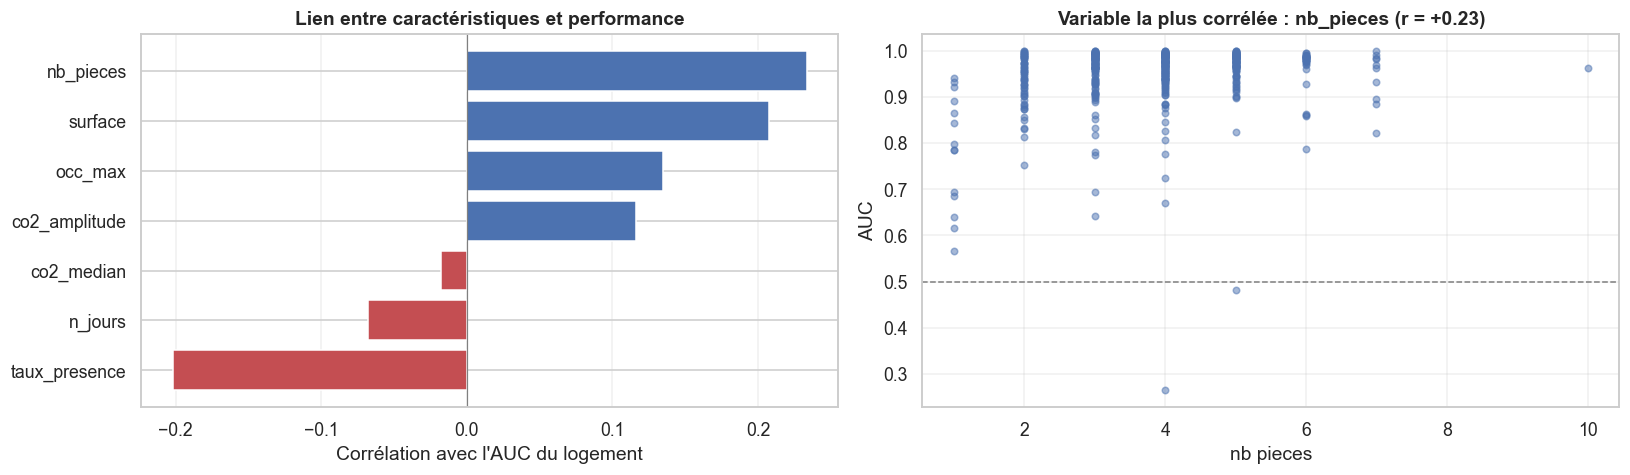

taux_presence   -0.202
n_jours         -0.068
co2_median      -0.018
co2_amplitude    0.116
occ_max          0.135
surface          0.208
nb_pieces        0.233


In [7]:
# ── Variables quantitatives : y a-t-il une tendance continue ?
QUANTI = ['surface', 'nb_pieces', 'taux_presence', 'co2_median', 'co2_amplitude',
          'n_jours', 'occ_max']
corr = P[QUANTI].corrwith(P['auc']).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
axes[0].barh(corr.index, corr.values,
             color=['#C44E52' if v < 0 else '#4C72B0' for v in corr.values])
axes[0].axvline(0, color='grey', lw=0.8)
axes[0].set_xlabel("Corrélation avec l'AUC du logement")
axes[0].set_title('Lien entre caractéristiques et performance', fontweight='bold')
axes[0].grid(True, axis='x', alpha=0.3)

v_max = corr.abs().idxmax()
axes[1].scatter(P[v_max], P['auc'], s=18, alpha=0.5, color='#4C72B0')
axes[1].axhline(0.5, color='grey', lw=1, ls='--')
axes[1].set_xlabel(v_max.replace('_', ' ')); axes[1].set_ylabel('AUC')
axes[1].set_title(f'Variable la plus corrélée : {v_max} '
                  f'(r = {corr[v_max]:+.2f})', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
print(corr.round(3).to_string())


In [ ]:
# ── Ces écarts sont-ils significatifs
from scipy.stats import kruskal, spearmanr

print('Variables qualitatives — test de Kruskal-Wallis')
print(f'{"variable":<20}{"p-value":>12}   interprétation')
for v in QUALI:
    sub = P.dropna(subset=[v])
    grp = [g['auc'].values for _, g in sub.groupby(v) if len(g) >= 10]
    if len(grp) < 2:
        continue
    p = kruskal(*grp).pvalue
    verdict = 'écart significatif' if p < 0.05 else 'pas de différence nette'
    print(f'{v:<20}{p:>12.4f}   {verdict}')

print('\nVariables quantitatives — corrélation de Spearman')
print(f'{"variable":<20}{"rho":>8}{"p-value":>12}   interprétation')
for v in QUANTI:
    sub = P.dropna(subset=[v])
    rho, p = spearmanr(sub[v], sub['auc'])
    verdict = 'lien significatif' if p < 0.05 else 'pas de lien net'
    print(f'{v:<20}{rho:>8.3f}{p:>12.4f}   {verdict}')


Variables qualitatives — test de Kruskal-Wallis
variable                 p-value   interprétation
ventilation               0.2209   pas de différence nette
type_logement             0.0000   écart significatif
structure_menage          0.0298   écart significatif
piece_capteur             0.0000   écart significatif

Variables quantitatives — corrélation de Spearman
variable                 rho     p-value   interprétation
surface                0.325      0.0000   lien significatif
nb_pieces              0.225      0.0000   lien significatif
taux_presence         -0.308      0.0000   lien significatif
co2_median            -0.062      0.1900   pas de lien net
co2_amplitude          0.119      0.0117   lien significatif
n_jours               -0.055      0.2459   pas de lien net
occ_max                0.059      0.2118   pas de lien net


Lien entre surface et performance
  brut                        : rho = +0.325  (p = 0.0000)
  à taux de présence contrôlé : rho = +0.320  (p = 0.0000)

Par tranche de surface :
                 logements  auc_mediane  presence_mediane
tranche_surface                                          
≤ 60 m²                 67        0.927             0.446
60-90 m²               134        0.964             0.397
90-120 m²               98        0.976             0.419
> 120 m²               142        0.981             0.404

Par tranche de taux de présence :
                  logements  auc_mediane
tranche_presence                        
(0.0, 0.25]              22        0.977
(0.25, 0.35]             56        0.974
(0.35, 0.45]            223        0.977
(0.45, 0.55]            100        0.947
(0.55, 1.0]              40        0.903


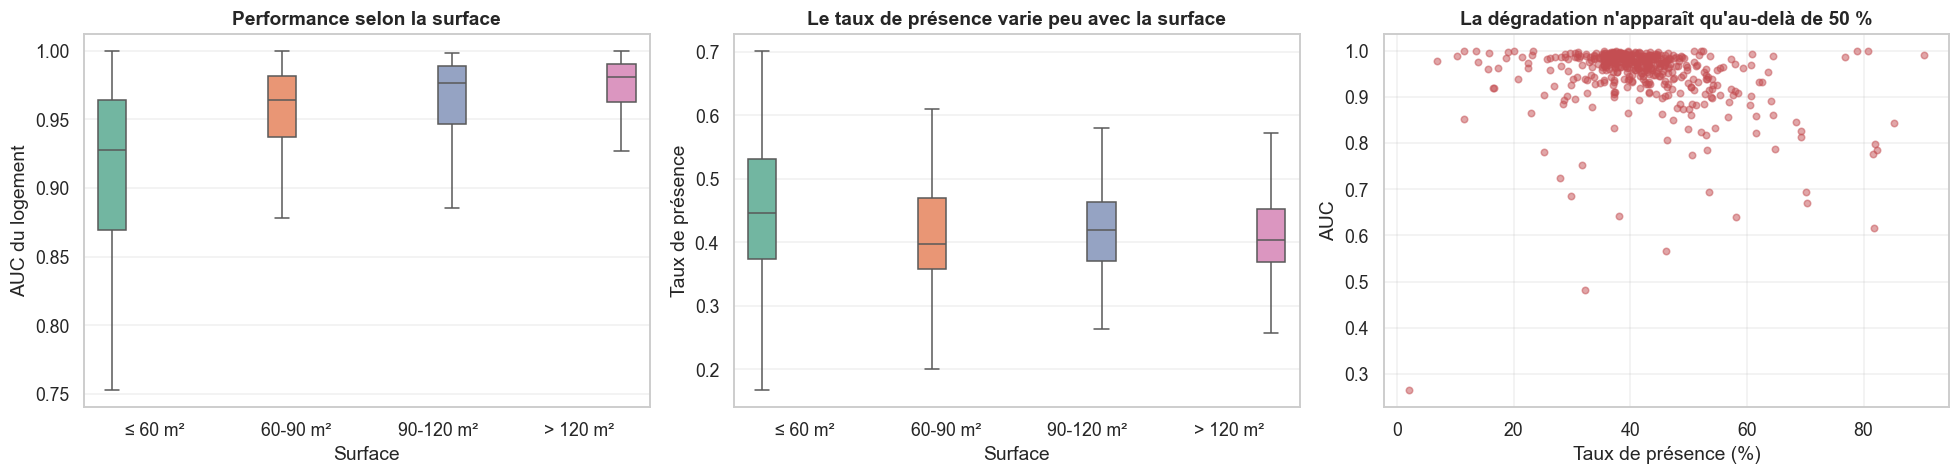

In [ ]:
#  la surface agit-elle directement, ou via l'occupation ?
from scipy.stats import spearmanr
import statsmodels.api as sm

sub = P.dropna(subset=['surface', 'taux_presence', 'auc']).copy()

def spearman_partiel(a, b, controle, D):
    """Corrélation de rang entre a et b, une fois retiré l'effet de `controle`.
    La résidualisation porte sur les RANGS : appliquer une régression linéaire aux
    valeurs brutes ne modifierait presque pas leur ordre, et laisserait donc le
    coefficient de Spearman inchangé."""
    ra, rb, rc = D[a].rank(), D[b].rank(), D[controle].rank()
    res_a = sm.OLS(ra, sm.add_constant(rc)).fit().resid
    res_b = sm.OLS(rb, sm.add_constant(rc)).fit().resid
    return spearmanr(res_a, res_b)

rho_brut, p_brut = spearmanr(sub['surface'], sub['auc'])
rho_part, p_part = spearman_partiel('surface', 'auc', 'taux_presence', sub)

print('Lien entre surface et performance')
print(f'  brut                        : rho = {rho_brut:+.3f}  (p = {p_brut:.4f})')
print(f'  à taux de présence contrôlé : rho = {rho_part:+.3f}  (p = {p_part:.4f})')

# Lecture par tranches : le taux de présence varie-t-il vraiment avec la surface ?
sub['tranche_surface'] = pd.cut(sub['surface'], [0, 60, 90, 120, 10_000],
                                labels=['≤ 60 m²', '60-90 m²', '90-120 m²', '> 120 m²'])
sub['tranche_presence'] = pd.cut(sub['taux_presence'], [0, .25, .35, .45, .55, 1.0])

print('\nPar tranche de surface :')
print(sub.groupby('tranche_surface', observed=True)
      .agg(logements=('auc', 'size'), auc_mediane=('auc', 'median'),
           presence_mediane=('taux_presence', 'median')).round(3).to_string())

print('\nPar tranche de taux de présence :')
print(sub.groupby('tranche_presence', observed=True)
      .agg(logements=('auc', 'size'), auc_mediane=('auc', 'median')).round(3).to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
sns.boxplot(data=sub, x='tranche_surface', y='auc', ax=axes[0],
            hue='tranche_surface', palette='Set2', legend=False, showfliers=False)
axes[0].set_xlabel('Surface'); axes[0].set_ylabel('AUC du logement')
axes[0].set_title('Performance selon la surface', fontweight='bold')
axes[0].grid(True, axis='y', alpha=0.3)

sns.boxplot(data=sub, x='tranche_surface', y='taux_presence', ax=axes[1],
            hue='tranche_surface', palette='Set2', legend=False, showfliers=False)
axes[1].set_xlabel('Surface'); axes[1].set_ylabel('Taux de présence')
axes[1].set_title('Le taux de présence varie peu avec la surface', fontweight='bold')
axes[1].grid(True, axis='y', alpha=0.3)

axes[2].scatter(sub['taux_presence'] * 100, sub['auc'], s=18, alpha=0.5, color='#C44E52')
axes[2].set_xlabel('Taux de présence (%)'); axes[2].set_ylabel('AUC')
axes[2].set_title('La dégradation n\'apparaît qu\'au-delà de 50 %', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


Régularité du rythme et performance : rho = +0.771  (p = 0.0000)

Surface et performance :
  brut                     : rho = +0.325
  à régularité contrôlée   : rho = +0.156  (p = 0.0010)


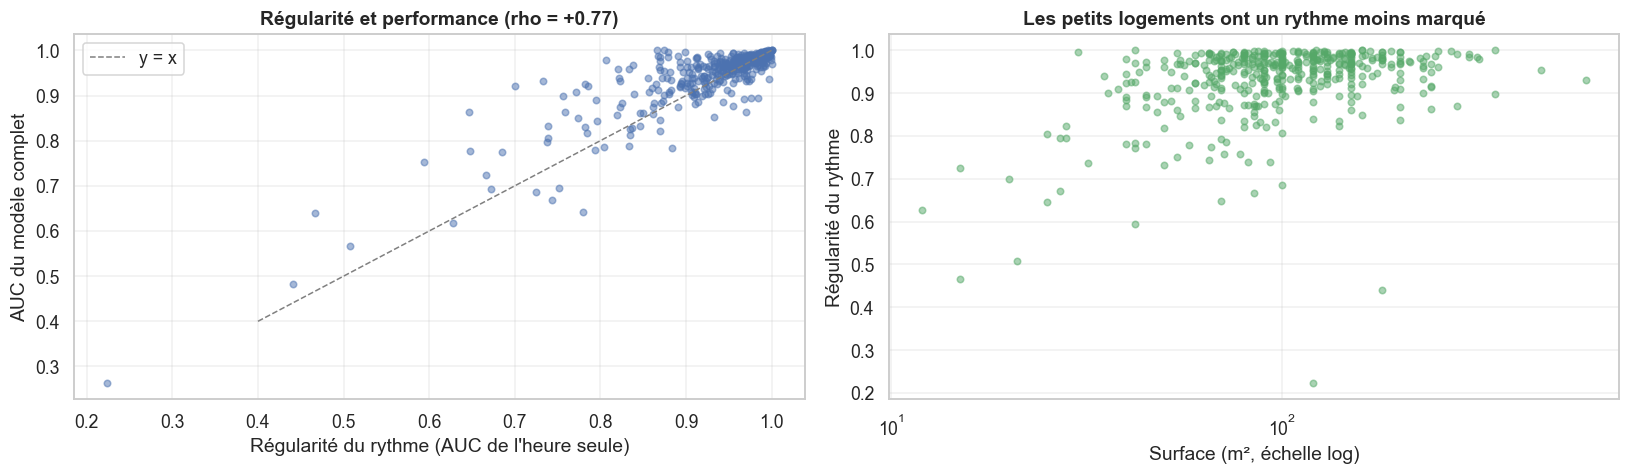

In [ ]:
# la régularité du rythme
d['proba_heure'] = np.nan
for itr, ite in GroupKFold(n_splits=5).split(d, groups=d['CODELIEU']):
    mh = HistGradientBoostingClassifier(random_state=42)
    mh.fit(d.loc[itr, ['heure_sin', 'heure_cos']], d.loc[itr, CIBLE].astype(int))
    d.loc[ite, 'proba_heure'] = mh.predict_proba(d.loc[ite, ['heure_sin', 'heure_cos']])[:, 1]

regul = d.groupby('CODELIEU').apply(lambda x: roc_auc_score(
    x[CIBLE].astype(int), x['proba_heure']) if x[CIBLE].nunique() > 1 else np.nan).dropna()
P['regularite'] = regul
Q = P.dropna(subset=['regularite', 'surface'])

rho_reg, p_reg = spearmanr(Q['regularite'], Q['auc'])
rho_surf_ctrl, p_surf_ctrl = spearman_partiel('surface', 'auc', 'regularite', Q)

print(f'Régularité du rythme et performance : rho = {rho_reg:+.3f}  (p = {p_reg:.4f})')
print(f'\nSurface et performance :')
print(f'  brut                     : rho = {spearmanr(Q["surface"], Q["auc"])[0]:+.3f}')
print(f'  à régularité contrôlée   : rho = {rho_surf_ctrl:+.3f}  (p = {p_surf_ctrl:.4f})')

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
axes[0].scatter(Q['regularite'], Q['auc'], s=18, alpha=0.5, color='#4C72B0')
axes[0].plot([0.4, 1], [0.4, 1], color='grey', lw=1, ls='--', label='y = x')
axes[0].set_xlabel('Régularité du rythme (AUC de l\'heure seule)')
axes[0].set_ylabel('AUC du modèle complet')
axes[0].set_title(f'Régularité et performance (rho = {rho_reg:+.2f})', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].scatter(Q['surface'], Q['regularite'], s=18, alpha=0.5, color='#55A868')
axes[1].set_xscale('log')
axes[1].set_xlabel('Surface (m², échelle log)'); axes[1].set_ylabel('Régularité du rythme')
axes[1].set_title('Les petits logements ont un rythme moins marqué', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


## 4. D'où vient la régularité du rythme ?

La régularité de l'occupation explique la performance mieux que toute
caractéristique du bâti. Reste à savoir ce qui la détermine.

L'hypothèse la plus naturelle concerne le **statut professionnel** : un ménage
d'actifs a des horaires contraints — départ le matin, retour le soir — et
devrait donc occuper sa chambre de façon plus régulière qu'un ménage sans
emploi, libre de ses journées.

Cette question rejoint l'objectif initial du travail. Les tentatives de
clustering cherchaient à relier le signal CO2 au profil des occupants sans y
parvenir ; la différence ici est que la quantité à expliquer n'est pas un groupe
construit arbitrairement, mais une **grandeur mesurée**.


In [11]:
# ── Statut professionnel des occupants (INDT)
INDT_LABELS = {'1': 'Travaille', '2': 'Étudiant', '3': 'Ne travaille pas'}

q_ind = pd.read_csv(f'{DATA}/Questionnaires_Comportement/CNL1_Q_INDIVIDU_DATA.csv',
                    sep=';', encoding='latin1',
                    usecols=['CODELIEU', 'NUM_OCCUPANT', 'INDT'], dtype={'INDT': str})
q_ind['statut'] = q_ind['INDT'].map(INDT_LABELS).fillna('Non renseigné / enfant')

# Caractérisation du ménage : la contrainte horaire vient des actifs et étudiants
menage = q_ind.groupby('CODELIEU').agg(
    n_occupants=('NUM_OCCUPANT', 'nunique'),
    n_actifs=('INDT', lambda s: (s == '1').sum()),
    n_contraints=('INDT', lambda s: s.isin(['1', '2']).sum()),   # actifs + étudiants
)
menage['part_contraints'] = menage['n_contraints'] / menage['n_occupants'].clip(lower=1)
menage['profil'] = np.where(
    menage['n_contraints'] == 0, 'Aucun horaire contraint',
    np.where(menage['part_contraints'] >= 0.5, 'Majorité contrainte', 'Minorité contrainte'))

R = P.join(menage).dropna(subset=['regularite', 'profil'])
print(f'{len(R)} logements avec statut professionnel renseigné\n')
print(R['profil'].value_counts().to_string())
print(f'\nNombre d\'actifs par logement :')
print(R['n_actifs'].value_counts().sort_index().to_string())


447 logements avec statut professionnel renseigné

profil
Majorité contrainte        312
Aucun horaire contraint     97
Minorité contrainte         38

Nombre d'actifs par logement :
n_actifs
0    108
1    147
2    169
3     20
4      3


Régularité du rythme selon le profil du ménage
                        regularite         auc        taux_presence       
                              size median size median          size median
profil                                                                    
Aucun horaire contraint         97  0.975   97  0.976            97  0.399
Majorité contrainte            312  0.954  312  0.969           312  0.411
Minorité contrainte             38  0.949   38  0.961            38  0.435

Test de Kruskal-Wallis : p = 0.0001   (écart significatif)
  n_actifs           rho = -0.043  (p = 0.3622)   pas de lien net
  part_contraints    rho = -0.175  (p = 0.0002)   lien significatif
  n_occupants        rho = +0.047  (p = 0.3193)   pas de lien net


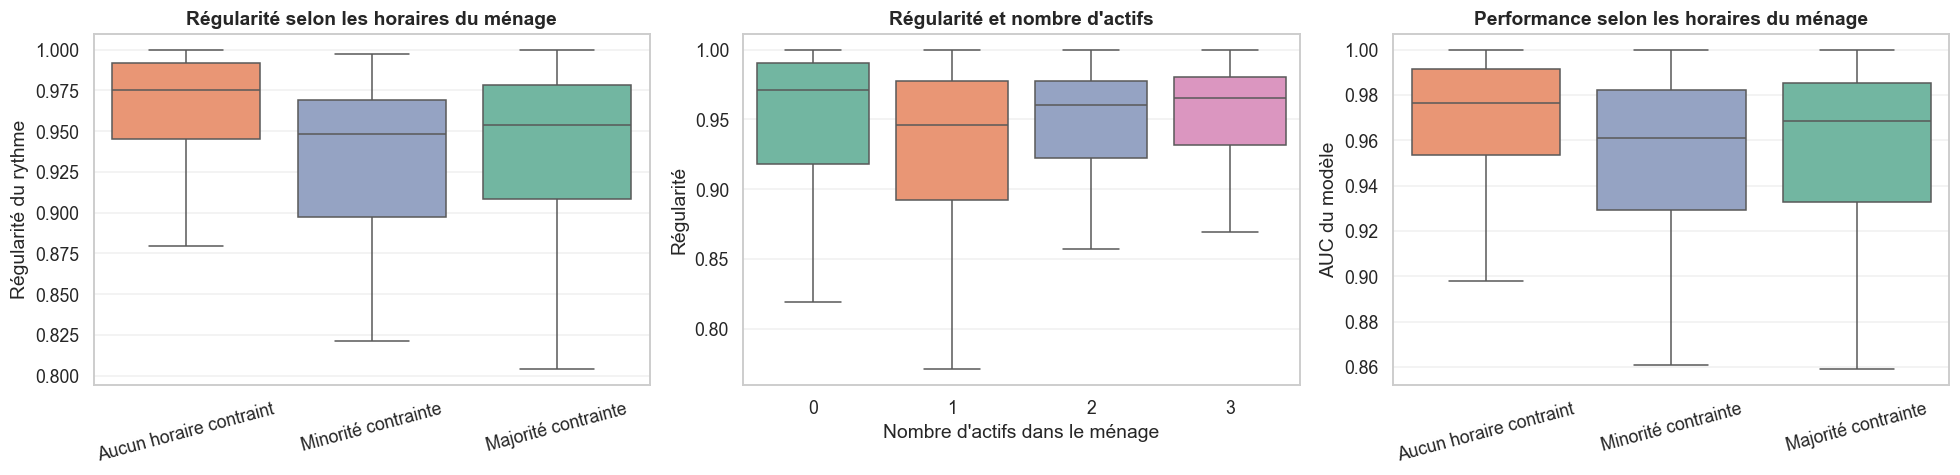

In [12]:
# ── La régularité dépend-elle du statut professionnel du ménage ?
from scipy.stats import kruskal, spearmanr

ordre = ['Aucun horaire contraint', 'Minorité contrainte', 'Majorité contrainte']
ordre = [o for o in ordre if (R['profil'] == o).sum() >= 10]

print('Régularité du rythme selon le profil du ménage')
print(R.groupby('profil')[['regularite', 'auc', 'taux_presence']]
      .agg(['size', 'median']).round(3).to_string())

grp = [R.loc[R['profil'] == o, 'regularite'].values for o in ordre]
p_kw = kruskal(*grp).pvalue
print(f'\nTest de Kruskal-Wallis : p = {p_kw:.4f}   '
      f'({"écart significatif" if p_kw < 0.05 else "pas de différence nette"})')

for v in ['n_actifs', 'part_contraints', 'n_occupants']:
    rho, p = spearmanr(R[v], R['regularite'])
    verdict = 'lien significatif' if p < 0.05 else 'pas de lien net'
    print(f'  {v:<18} rho = {rho:+.3f}  (p = {p:.4f})   {verdict}')

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

sns.boxplot(data=R[R['profil'].isin(ordre)], x='profil', y='regularite', order=ordre,
            ax=axes[0], hue='profil', palette='Set2', legend=False, showfliers=False)
axes[0].set_xlabel(''); axes[0].set_ylabel('Régularité du rythme')
axes[0].set_title('Régularité selon les horaires du ménage', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(True, axis='y', alpha=0.3)

sns.boxplot(data=R[R['n_actifs'] <= 3], x='n_actifs', y='regularite', ax=axes[1],
            hue='n_actifs', palette='Set2', legend=False, showfliers=False)
axes[1].set_xlabel('Nombre d\'actifs dans le ménage'); axes[1].set_ylabel('Régularité')
axes[1].set_title('Régularité et nombre d\'actifs', fontweight='bold')
axes[1].grid(True, axis='y', alpha=0.3)

sns.boxplot(data=R[R['profil'].isin(ordre)], x='profil', y='auc', order=ordre,
            ax=axes[2], hue='profil', palette='Set2', legend=False, showfliers=False)
axes[2].set_xlabel(''); axes[2].set_ylabel('AUC du modèle')
axes[2].set_title('Performance selon les horaires du ménage', fontweight='bold')
axes[2].tick_params(axis='x', rotation=15)
axes[2].grid(True, axis='y', alpha=0.3)

plt.tight_layout(); plt.show()


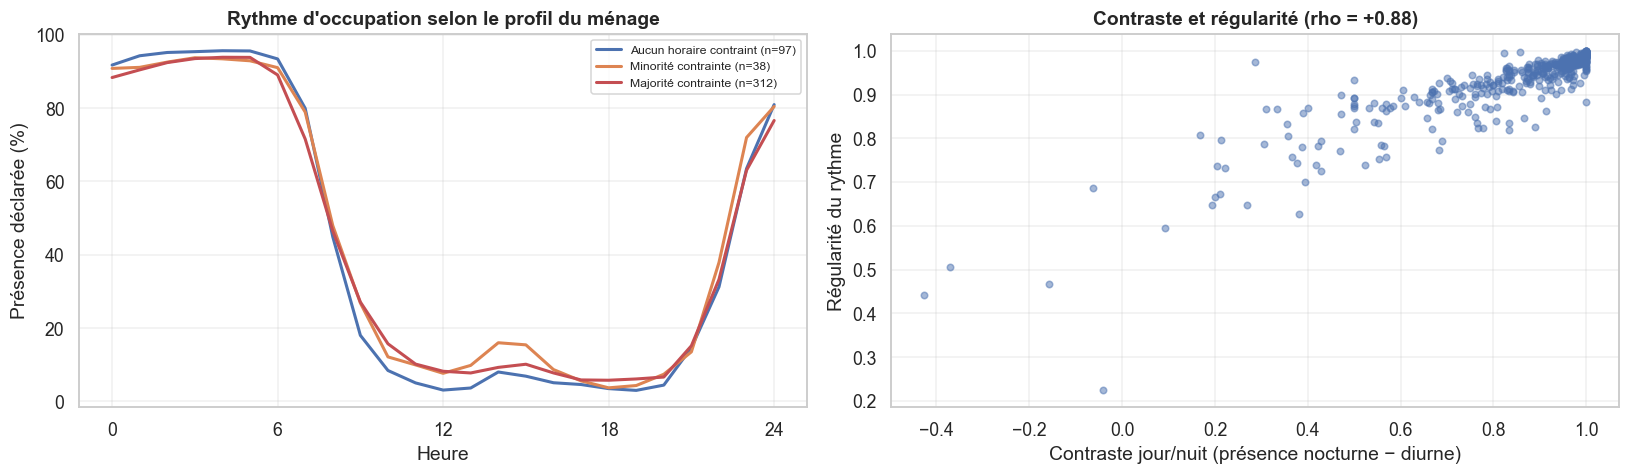

Contraste jour/nuit selon le profil :
                         size  median
profil                               
Aucun horaire contraint    97   0.958
Majorité contrainte       312   0.917
Minorité contrainte        38   0.828

Corrélation contraste / régularité : rho = +0.883  (p = 0.0000)


In [13]:
# ── Lecture directe : le rythme d'occupation heure par heure
d_prof = d.merge(R[['profil']], left_on='CODELIEU', right_index=True, how='inner')

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

for prof, color in zip(ordre, ['#4C72B0', '#DD8452', '#C44E52']):
    sub = d_prof[d_prof['profil'] == prof]
    courbe = sub.groupby(sub['heure'].round(0))[CIBLE].mean() * 100
    axes[0].plot(courbe.index, courbe.values, lw=2, color=color,
                 label=f'{prof} (n={sub["CODELIEU"].nunique()})')
axes[0].set_xlabel('Heure'); axes[0].set_ylabel('Présence déclarée (%)')
axes[0].set_xticks([0, 6, 12, 18, 24])
axes[0].set_title('Rythme d\'occupation selon le profil du ménage', fontweight='bold')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

# Contraste jour/nuit : présence nocturne moyenne moins présence diurne.
# Une amplitude définie comme max − min saturerait à 1 dès qu'un logement connaît
# une heure pleinement occupée et une heure vide — ce qui est le cas de presque
# tous. Comparer deux moyennes sur plusieurs heures évite cet effet de plafond.
nuit = d_prof[d_prof['heure'] < 6].groupby('CODELIEU')[CIBLE].mean()
jour = d_prof[(d_prof['heure'] >= 10) & (d_prof['heure'] < 16)].groupby('CODELIEU')[CIBLE].mean()
R['contraste_jour_nuit'] = (nuit - jour)

valid = R.dropna(subset=['contraste_jour_nuit', 'regularite'])
rho_c, p_c = spearmanr(valid['contraste_jour_nuit'], valid['regularite'])

axes[1].scatter(R['contraste_jour_nuit'], R['regularite'], s=18, alpha=0.5, color='#4C72B0')
axes[1].set_xlabel('Contraste jour/nuit (présence nocturne − diurne)')
axes[1].set_ylabel('Régularité du rythme')
axes[1].set_title(f'Contraste et régularité (rho = {rho_c:+.2f})', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print('Contraste jour/nuit selon le profil :')
print(R.groupby('profil')['contraste_jour_nuit'].agg(['size', 'median']).round(3).to_string())
print(f'\nCorrélation contraste / régularité : rho = {rho_c:+.3f}  (p = {p_c:.4f})')


In [1]:
# ── Vérification : l'alternance semaine/week-end explique-t-elle l'écart ?
d['we'] = d['DATE'].dt.dayofweek >= 5

def regularite_sur(masque, nom):
    """Régularité (AUC d'un modèle n'utilisant que l'heure) sur un sous-ensemble
    de jours, estimée par validation croisée par logement."""
    sous = d[masque].reset_index(drop=True).copy()
    sous['p'] = np.nan
    for itr, ite in GroupKFold(n_splits=5).split(sous, groups=sous['CODELIEU']):
        mh = HistGradientBoostingClassifier(random_state=42)
        mh.fit(sous.loc[itr, ['heure_sin', 'heure_cos']], sous.loc[itr, CIBLE].astype(int))
        sous.loc[ite, 'p'] = mh.predict_proba(sous.loc[ite, ['heure_sin', 'heure_cos']])[:, 1]
    r = sous.groupby('CODELIEU').apply(
        lambda x: roc_auc_score(x[CIBLE].astype(int), x['p'])
        if x[CIBLE].nunique() > 1 else np.nan)
    print(f'  {nom:<12} {masque.sum():>7,} obs · {r.notna().sum():>3} logements évaluables')
    return r.dropna()

print('Calcul de la régularité par type de jour :')
reg_sem = regularite_sur(~d['we'], 'semaine')
reg_we  = regularite_sur(d['we'],  'week-end')

W = R.join(reg_sem.rename('reg_semaine')).join(reg_we.rename('reg_weekend'))
W = W.dropna(subset=['reg_semaine', 'reg_weekend', 'profil'])
W['ecart'] = W['reg_semaine'] - W['reg_weekend']

print(f'\n{len(W)} logements évaluables sur les deux périodes\n')
print('Régularité selon le type de jour et le profil du ménage')
print(W.groupby('profil')[['reg_semaine', 'reg_weekend', 'ecart']]
      .agg(['size', 'median']).round(3).to_string())

grp = [W.loc[W['profil'] == o, 'ecart'].values for o in ordre if (W['profil'] == o).sum() >= 10]
p_ecart = kruskal(*grp).pvalue if len(grp) >= 2 else np.nan



NameError: name 'd' is not defined

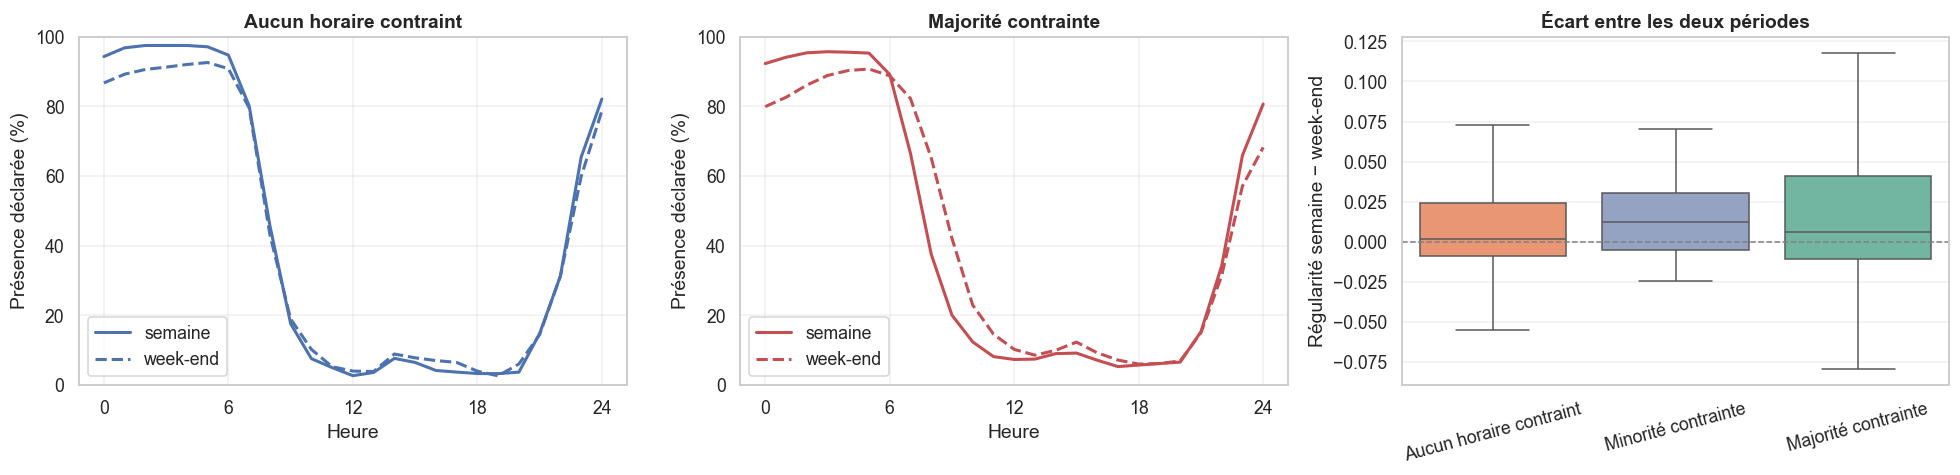

In [15]:
# Lecture directe : le rythme d'occupation, semaine contre week-end
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

d_w = d.merge(R[['profil']], left_on='CODELIEU', right_index=True, how='inner')
for ax, (prof, color) in zip(axes[:2], [(ordre[0], '#4C72B0'), (ordre[-1], '#C44E52')]):
    sub = d_w[d_w['profil'] == prof]
    for we, style, lab in [(False, '-', 'semaine'), (True, '--', 'week-end')]:
        courbe = sub[sub['we'] == we].groupby(sub['heure'].round(0))[CIBLE].mean() * 100
        ax.plot(courbe.index, courbe.values, style, lw=2, color=color, label=lab)
    ax.set_xlabel('Heure'); ax.set_ylabel('Présence déclarée (%)')
    ax.set_xticks([0, 6, 12, 18, 24]); ax.set_ylim(0, 100)
    ax.set_title(prof, fontweight='bold'); ax.legend(); ax.grid(True, alpha=0.3)

sns.boxplot(data=W[W['profil'].isin(ordre)], x='profil', y='ecart', order=ordre,
            ax=axes[2], hue='profil', palette='Set2', legend=False, showfliers=False)
axes[2].axhline(0, color='grey', lw=1, ls='--')
axes[2].set_xlabel(''); axes[2].set_ylabel('Régularité semaine − week-end')
axes[2].set_title('Écart entre les deux périodes', fontweight='bold')
axes[2].tick_params(axis='x', rotation=15); axes[2].grid(True, axis='y', alpha=0.3)

plt.tight_layout(); plt.show()


## 5. Synthèse

### La ventilation ne joue aucun rôle

C'était l'hypothèse la plus intuitive : un renouvellement d'air rapide évacue le
CO2 avant qu'il ne s'accumule et devrait brouiller le lien entre occupation et
signal. **Elle est infirmée.**

| Ventilation | Logements | AUC médiane |
|---|---|---|
| Extracteurs | 43 | 0.976 |
| VMC | 170 | 0.973 |
| Naturelle | 145 | 0.967 |
| Aucune | 89 | 0.964 |

Douze millièmes d'écart entre les extrêmes, non significatif (p = 0.22). Le
modèle s'accommode de régimes de ventilation très différents — c'est une bonne
nouvelle pour sa robustesse.

### Le facteur déterminant est la régularité du rythme

En mesurant, pour chaque logement, ce qu'un modèle **n'utilisant que l'heure**
parvient à prédire, on obtient un indicateur de la régularité de son occupation.
Sa corrélation avec la performance du modèle complet est de **+0.77** — sans
commune mesure avec le reste :

| Facteur | Corrélation avec l'AUC |
|---|---|
| **Régularité du rythme** | **+0.77** |
| Surface | +0.33 |
| Taux de présence | −0.31 |
| Nombre de pièces | +0.23 |

L'interprétation prolonge ce qui avait déjà été établi : le modèle s'appuie
massivement sur le rythme circadien, le CO2 venant corriger cette base. Un
logement dont l'occupation suit un cycle net lui est facile ; une occupation
irrégulière le prive de son principal repère.

### La surface n'agit qu'indirectement

| Surface | Logements | AUC médiane | Taux de présence |
|---|---|---|---|
| ≤ 60 m² | 67 | 0.927 | 0.446 |
| 60-90 m² | 134 | 0.964 | 0.397 |
| 90-120 m² | 98 | 0.976 | 0.419 |
| > 120 m² | 142 | 0.981 | 0.404 |

Le taux de présence reste stable d'une tranche à l'autre : l'écart ne vient pas
de là. En revanche, une fois la **régularité** neutralisée, la corrélation de la
surface chute de +0.33 à +0.16 — plus de la moitié de son effet transite par elle.

Le mécanisme se lit sur les **studios**, seul groupe nettement distinct (AUC
0.791 contre 0.971, sur 14 logements) : dans une pièce unique, l'occupant présent
chez lui s'y trouve nécessairement, à toute heure. Le rythme « chambre »
disparaît, et avec lui le repère principal du modèle.

### L'hypothèse du statut professionnel est infirmée — et inversée

On attendait des ménages d'actifs, aux horaires contraints, une occupation plus
régulière. C'est **l'inverse** qui s'observe :

| Profil du ménage | Logements | Régularité | Contraste jour/nuit |
|---|---|---|---|
| **Aucun horaire contraint** | 97 | **0.975** | **0.958** |
| Majorité contrainte | 312 | 0.954 | 0.917 |
| Minorité contrainte | 38 | 0.949 | 0.828 |

L'écart est significatif (Kruskal-Wallis, p = 0.0001) et la part d'occupants
contraints corrèle **négativement** avec la régularité (rho = −0.175, p = 0.0002).

**L'explication par l'alternance semaine/week-end ne tient pas.** L'hypothèse
était qu'un ménage d'actifs suit un rythme contraint du lundi au vendredi puis
s'en affranchit le week-end, cette alternance réduisant sa régularité mesurée sur
l'ensemble des jours. La vérification l'écarte :

| Profil du ménage | Semaine | Week-end | Écart |
|---|---|---|---|
| Aucun horaire contraint | 0.981 | 0.980 | 0.002 |
| Majorité contrainte | 0.968 | 0.958 | 0.006 |
| Minorité contrainte | 0.964 | 0.948 | 0.012 |

Les écarts sont négligeables et ne diffèrent pas significativement selon le
profil (p = 0.37). Surtout, **la hiérarchie entre profils se retrouve à
l'identique dans les deux périodes** : les ménages sans horaire contraint sont
plus réguliers en semaine comme le week-end.

Ce n'est donc pas l'alternance travail/repos qui est en cause, mais une stabilité
d'habitudes plus générale. Le mécanisme reste à élucider. La taille du ménage est
écartée (aucune corrélation avec la régularité : rho = +0.047, p = 0.32) ; restent
des pistes non testées ici, comme l'âge des occupants — un ménage retraité
pouvant suivre des horaires de sommeil plus constants — ou la présence d'enfants,
susceptibles d'occuper les chambres en journée.

Le contraste jour/nuit confirme le mécanisme : sa corrélation avec la régularité
atteint **+0.88**, et il suit le même ordre entre profils.

### Ce que cela dit des tentatives de clustering

Aucune caractéristique **structurelle** du logement — ventilation, type, ménage —
n'explique substantiellement la performance. Ce qui compte est un trait
d'**usage** : la régularité du rythme de vie, que le statut professionnel ne
prédit que faiblement et dans un sens contre-intuitif.

C'est une explication solide de l'échec des regroupements tentés précédemment :
il n'existe pas de « types de logements » lisibles dans la dynamique du CO2. Les
logements se distinguent par la manière dont ils sont habités, et cette manière
ne se déduit pas des questionnaires.

### Une précaution de lecture

L'AUC médiane par logement (0.97) dépasse l'AUC globale (0.939). L'explication
est celle déjà rencontrée : à l'intérieur d'un logement, l'alternance jour/nuit
suffit à ordonner correctement les probabilités. Ce chiffre mesure la cohérence
interne des prédictions, non la valeur du signal — seule la décomposition par
créneau horaire y répond.
